In [ ]:
# Lab3 AI in Health Care

In [1]:
# ============================================================
# LAB ASSIGNMENT - 3
# AI IN HEALTHCARE
# Multimodal Medical Data Processing
# ============================================================

!pip -q install wfdb opencv-python-headless nltk scikit-image \
    scipy statsmodels kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.5 MB/s eta 0:00:00


In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import re
import glob
import zipfile
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from scipy import stats
from scipy.signal import butter, filtfilt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

import cv2
from PIL import Image

import wfdb

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


Part A


In [3]:
# ============================================================
# PART A: TABULAR DATA
# PIMA INDIANS DIABETES DATASET
# ============================================================

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

diabetes_df = pd.read_csv(
    url,
    names=columns
)

print("Pima Indians Diabetes Dataset loaded successfully!")
print("Shape:", diabetes_df.shape)

display(diabetes_df.head())

Pima Indians Diabetes Dataset loaded successfully!
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# ============================================================
# DATASET INSPECTION
# ============================================================

print("Number of rows:", diabetes_df.shape[0])
print("Number of columns:", diabetes_df.shape[1])

print("\nColumn names:")
print(diabetes_df.columns.tolist())

print("\nData types:")
print(diabetes_df.dtypes)

print("\nBasic information:")
diabetes_df.info()

Number of rows: 768
Number of columns: 9

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Basic information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin  

In [5]:
# ============================================================
# HEALTHCARE-SPECIFIC MISSING VALUE DETECTION
# ============================================================

columns_with_zero_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Zero values before cleaning:\n")

for col in columns_with_zero_missing:
    count = (diabetes_df[col] == 0).sum()
    print(f"{col}: {count}")

Zero values before cleaning:

Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


In [6]:
# ============================================================
# CONVERT IMPLAUSIBLE ZERO VALUES TO NaN
# ============================================================

diabetes_clean = diabetes_df.copy()

for col in columns_with_zero_missing:
    diabetes_clean[col] = diabetes_clean[col].replace(0, np.nan)

print("Missing values after converting invalid zeros:")

display(diabetes_clean.isnull().sum().to_frame("Missing Values"))

Missing values after converting invalid zeros:


,Missing Values
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
# ============================================================
# IMPUTE MISSING VALUES
# MEDIAN IS USED BECAUSE IT IS ROBUST TO OUTLIERS
# ============================================================

for col in columns_with_zero_missing:

    median_value = diabetes_clean[col].median()

    diabetes_clean[col] = diabetes_clean[col].fillna(
        median_value
    )

print("Missing values after median imputation:")

display(diabetes_clean.isnull().sum().to_frame("Missing Values"))

Missing values after median imputation:


,Missing Values
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


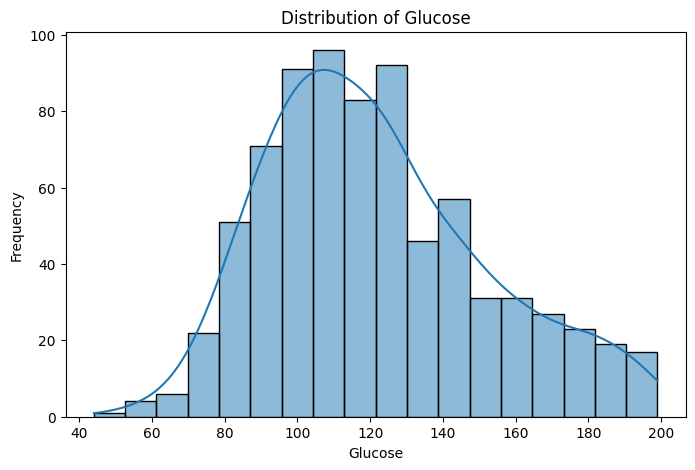

In [8]:
# ============================================================
# EDA - GLUCOSE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    diabetes_clean["Glucose"],
    kde=True
)

plt.title("Distribution of Glucose")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.show()

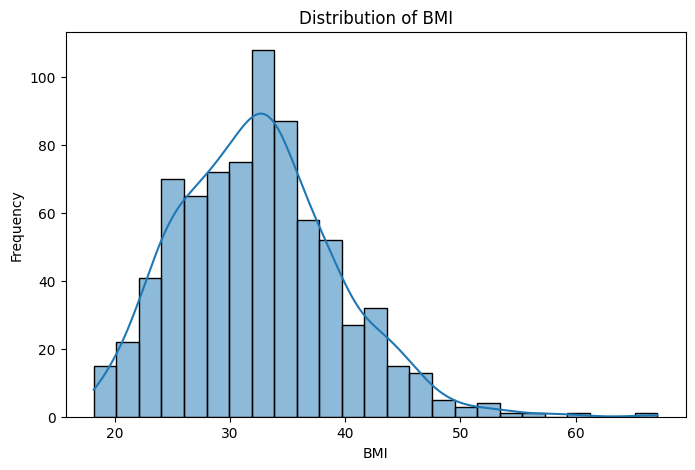

In [9]:
# ============================================================
# EDA - BMI DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    diabetes_clean["BMI"],
    kde=True
)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

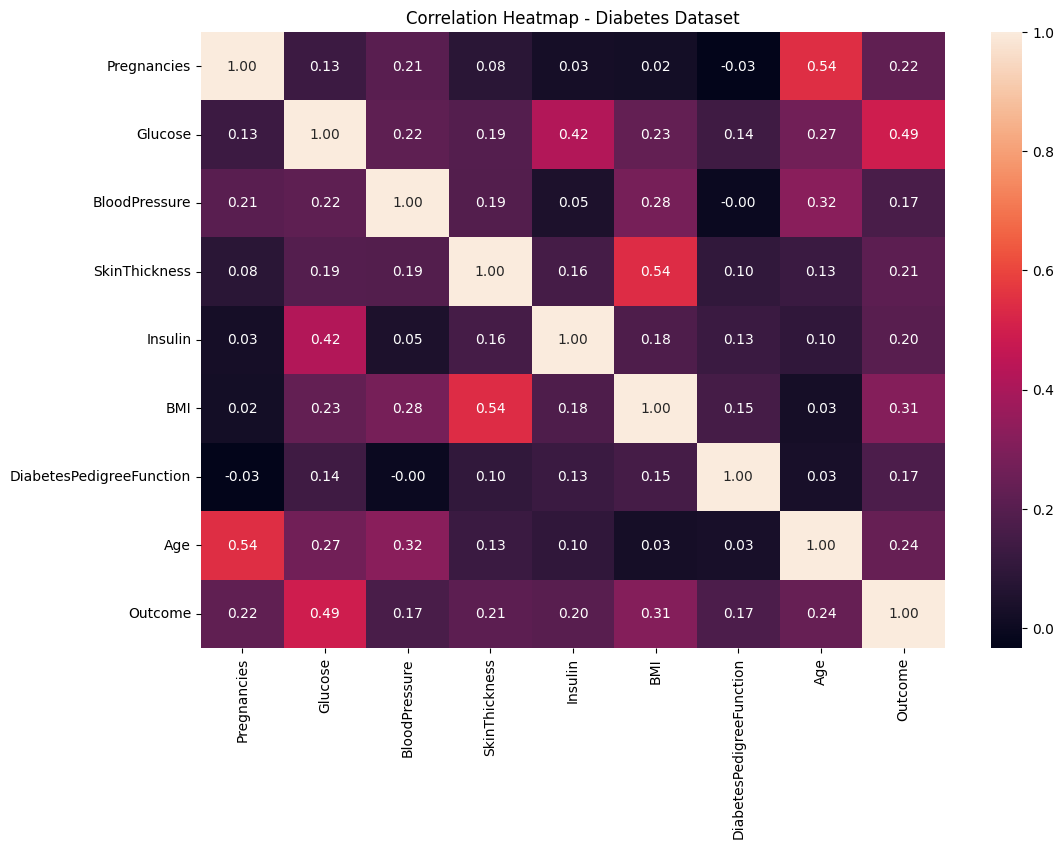

In [10]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(12, 8))

sns.heatmap(
    diabetes_clean.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap - Diabetes Dataset")

plt.show()

In [11]:
# ============================================================
# HYPOTHESIS TEST
# TWO-SAMPLE T-TEST
# ============================================================

diabetic = diabetes_clean[
    diabetes_clean["Outcome"] == 1
]["Glucose"]

non_diabetic = diabetes_clean[
    diabetes_clean["Outcome"] == 0
]["Glucose"]

t_stat, p_value = stats.ttest_ind(
    diabetic,
    non_diabetic,
    equal_var=False
)

print("Two-Sample T-Test")
print("------------------")

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nResult: Reject H0")
    print("There is a statistically significant difference.")
else:
    print("\nResult: Fail to reject H0")
    print("There is no statistically significant difference.")

Two-Sample T-Test
------------------
T-statistic: 14.852653441079662
P-value: 3.5421485614431447e-41

Result: Reject H0
There is a statistically significant difference.


In [12]:
# ============================================================
# CHI-SQUARE TEST

# BMI category
 #     vs
#Diabetes Outcome
# ============================================================

diabetes_clean["BMI_Category"] = pd.cut(
    diabetes_clean["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ]
)

contingency_table = pd.crosstab(
    diabetes_clean["BMI_Category"],
    diabetes_clean["Outcome"]
)

print("Contingency Table:")
display(contingency_table)

chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("\nChi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p_value)

if p_value < 0.05:
    print("\nResult: Significant association found.")
else:
    print("\nResult: No significant association found.")

Contingency Table:


Outcome,0,1
BMI_Category,,
Underweight,4,0
Normal,101,7
Overweight,136,44
Obese,259,217



Chi-square statistic: 73.13331881767633
Degrees of freedom: 3
P-value: 9.101656268510895e-16

Result: Significant association found.


In [13]:
# ============================================================
# ONE-WAY ANOVA
# ============================================================

groups = []

for category in diabetes_clean["BMI_Category"].dropna().unique():

    group = diabetes_clean[
        diabetes_clean["BMI_Category"] == category
    ]["Glucose"]

    groups.append(group)

f_stat, p_value = stats.f_oneway(*groups)

print("One-Way ANOVA")
print("-------------")

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("\nResult: Significant difference exists between groups.")
else:
    print("\nResult: No significant difference between groups.")

One-Way ANOVA
-------------
F-statistic: 13.254241118590004
P-value: 1.9249439734881206e-08

Result: Significant difference exists between groups.


In [14]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

diabetes_clean["BMI_Glucose_Ratio"] = (
    diabetes_clean["BMI"] /
    (diabetes_clean["Glucose"] + 1)
)

diabetes_clean["Age_Glucose_Interaction"] = (
    diabetes_clean["Age"] *
    diabetes_clean["Glucose"]
)

diabetes_clean["Pregnancy_Age_Ratio"] = (
    diabetes_clean["Pregnancies"] /
    (diabetes_clean["Age"] + 1)
)

display(diabetes_clean.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,BMI_Glucose_Ratio,Age_Glucose_Interaction,Pregnancy_Age_Ratio
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,Obese,0.225503,7400.0,0.117647
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,Overweight,0.309302,2635.0,0.031250
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,Normal,0.126630,5856.0,0.242424
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight,0.312222,1869.0,0.045455
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Obese,0.312319,4521.0,0.000000


In [15]:
# ============================================================
# FEATURE SELECTION
# ============================================================

feature_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "BMI_Glucose_Ratio",
    "Age_Glucose_Interaction",
    "Pregnancy_Age_Ratio"
]

X = diabetes_clean[feature_columns]
y = diabetes_clean["Outcome"]

selector = SelectKBest(
    score_func=f_classif,
    k=5
)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[
    selector.get_support()
]

print("Selected Features:")
print(selected_features.tolist())

print("\nSelected feature matrix shape:")
print(X_selected.shape)

Selected Features:
['Pregnancies', 'Glucose', 'BMI', 'Age', 'Age_Glucose_Interaction']

Selected feature matrix shape:
(768, 5)


In [16]:
# ============================================================
# FEATURE EXTRACTION - PCA
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X.shape[1])
print("PCA features:", X_pca.shape[1])

print(
    "\nExplained variance ratio:",
    pca.explained_variance_ratio_
)

Original number of features: 11
PCA features: 2

Explained variance ratio: [0.29728306 0.18177257]


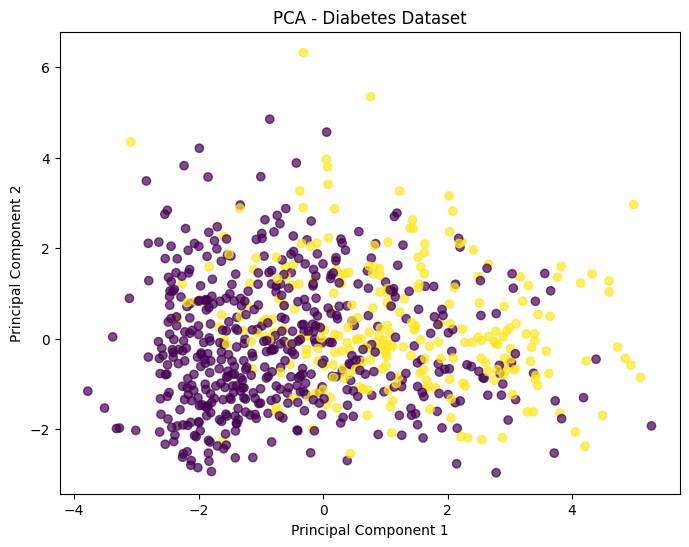

In [17]:
# ============================================================
# PCA VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Diabetes Dataset")

plt.show()

Part B

In [18]:
# ============================================================
# PART B: TEXTUAL DATA
# MTSAMPLES MEDICAL TRANSCRIPTIONS
# ============================================================

mtsamples_url = (
    "https://raw.githubusercontent.com/"
    "salgadev/medical-nlp/master/data/mtsamples.csv"
)

try:

    text_df = pd.read_csv(mtsamples_url)

    print("MTSamples dataset loaded successfully!")
    print("Shape:", text_df.shape)

    display(text_df.head())

except Exception as e:

    print("Could not download MTSamples automatically.")
    print("Please upload mtsamples.csv manually in Colab.")
    print("Error:", e)

MTSamples dataset loaded successfully!
Shape: (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [19]:
# ============================================================
# INSPECT TEXT DATA
# ============================================================

print("Columns:")
print(text_df.columns.tolist())

print("\nDataset information:")
text_df.info()

print("\nMissing values:")
display(text_df.isnull().sum().to_frame("Missing Values"))

Columns:
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB

Missing values:


,Missing Values
Unnamed: 0,0
description,0
medical_specialty,0
sample_name,0
transcription,33
keywords,1068


In [20]:
# ============================================================
# FIND TEXT COLUMN
# ============================================================

possible_text_columns = [
    "transcription",
    "transcription_text",
    "text"
]

text_column = None

for col in possible_text_columns:

    if col in text_df.columns:
        text_column = col
        break

if text_column is None:

    # Automatically choose the longest text-like column
    object_columns = text_df.select_dtypes(
        include="object"
    ).columns

    text_column = max(
        object_columns,
        key=lambda c: text_df[c].astype(str).str.len().mean()
    )

print("Text column selected:", text_column)

Text column selected: transcription


In [21]:
# ============================================================
# PHI REMOVAL / DE-IDENTIFICATION
# ============================================================

def remove_phi(text):

    text = str(text)

    # Email addresses
    text = re.sub(
        r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b',
        '[EMAIL]',
        text
    )

    # Phone numbers
    text = re.sub(
        r'\b(?:\+?\d{1,3}[-.\s]?)?\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b',
        '[PHONE]',
        text
    )

    # Dates
    text = re.sub(
        r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b',
        '[DATE]',
        text
    )

    # Patient IDs
    text = re.sub(
        r'\b(?:patient|pt)[\s_-]*id[:\s]*\w+\b',
        '[PATIENT_ID]',
        text,
        flags=re.IGNORECASE
    )

    return text


text_df["clean_text"] = (
    text_df[text_column]
    .fillna("")
    .apply(remove_phi)
)

print("PHI removal/de-identification completed.")

display(
    text_df[[text_column, "clean_text"]].head()
)

PHI removal/de-identification completed.


,transcription,clean_text
0,"SUBJECTIVE:, This 23-year-old white female pr...","SUBJECTIVE:, This 23-year-old white female pr..."
1,"PAST MEDICAL HISTORY:, He has difficulty climb...","PAST MEDICAL HISTORY:, He has difficulty climb..."
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","HISTORY OF PRESENT ILLNESS: , I have seen ABC ..."
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...","2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,1. The left ventricular cavity size and wall ...,1. The left ventricular cavity size and wall ...


In [22]:
# ============================================================
# NLP PREPROCESSING
# ============================================================

def preprocess_text(text):

    text = str(text).lower()

    # Keep only alphabetic characters
    text = re.sub(
        r'[^a-z\s]',
        ' ',
        text
    )

    # Tokenization
    tokens = text.split()

    # Basic stopword list
    stopwords = {
        "the", "is", "a", "an", "and",
        "of", "to", "in", "for", "on",
        "with", "was", "were", "this",
        "that", "patient"
    }

    tokens = [
        word for word in tokens
        if word not in stopwords
    ]

    return tokens


text_df["tokens"] = (
    text_df["clean_text"]
    .apply(preprocess_text)
)

display(
    text_df[
        ["clean_text", "tokens"]
    ].head()
)

,clean_text,tokens
0,"SUBJECTIVE:, This 23-year-old white female pr...","[subjective, year, old, white, female, present..."
1,"PAST MEDICAL HISTORY:, He has difficulty climb...","[past, medical, history, he, has, difficulty, ..."
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","[history, present, illness, i, have, seen, abc..."
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...","[d, m, mode, left, atrial, enlargement, left, ..."
4,1. The left ventricular cavity size and wall ...,"[left, ventricular, cavity, size, wall, thickn..."


In [23]:
# ============================================================
# WORD FREQUENCY ANALYSIS
# ============================================================

all_words = []

for tokens in text_df["tokens"]:

    all_words.extend(tokens)

word_frequency = Counter(all_words)

print("Most common medical/text words:")

for word, count in word_frequency.most_common(20):

    print(
        f"{word}: {count}"
    )

Most common medical/text words:
no: 17874
she: 17593
he: 15544
at: 13500
then: 12430
right: 11587
left: 11258
has: 10980
as: 10877
or: 10733
her: 10174
there: 9731
history: 9509
had: 8205
his: 7989
be: 7707
normal: 7526
procedure: 7463
placed: 7028
not: 6897


In [24]:
# ============================================================
# MEDICAL KEYWORD EXTRACTION
# ============================================================

medical_keywords = [
    "diabetes",
    "hypertension",
    "pain",
    "blood",
    "heart",
    "chest",
    "fever",
    "cancer",
    "infection",
    "surgery",
    "medication",
    "pressure",
    "glucose",
    "kidney",
    "lung"
]

def extract_medical_keywords(tokens):

    found = []

    for word in tokens:

        if word in medical_keywords:
            found.append(word)

    return list(set(found))


text_df["medical_keywords"] = (
    text_df["tokens"]
    .apply(extract_medical_keywords)
)

display(
    text_df[
        ["tokens", "medical_keywords"]
    ].head(10)
)

,tokens,medical_keywords
0,"[subjective, year, old, white, female, present...","[medication, pressure, blood]"
1,"[past, medical, history, he, has, difficulty, ...","[chest, cancer, diabetes, hypertension, pressu..."
2,"[history, present, illness, i, have, seen, abc...","[chest, cancer, diabetes, hypertension, pressu..."
3,"[d, m, mode, left, atrial, enlargement, left, ...",[pressure]
4,"[left, ventricular, cavity, size, wall, thickn...","[hypertension, pressure]"
5,"[preoperative, diagnosis, morbid, obesity, pos...","[surgery, pressure]"
6,"[preoperative, diagnoses, deformity, right, br...","[chest, blood]"
7,"[d, echocardiogram, multiple, views, heart, gr...",[heart]
8,"[preoperative, diagnosis, lipodystrophy, abdom...",[blood]
9,"[description, normal, cardiac, chambers, size,...",[]


In [25]:
# ============================================================
# TEXT → NUMERICAL SEQUENCES
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

X_text = vectorizer.fit_transform(
    text_df["clean_text"]
)

print("TF-IDF matrix created!")
print("Shape:", X_text.shape)

TF-IDF matrix created!
Shape: (4999, 1000)


Part C

In [26]:
# ============================================================
# PART C: IMAGE DATA
# CHEST X-RAY PNEUMONIA DATASET
# ============================================================

import kagglehub

try:

    dataset_path = kagglehub.dataset_download(
        "paultimothymooney/chest-xray-pneumonia"
    )

    print("Chest X-Ray dataset downloaded!")
    print("Dataset location:")
    print(dataset_path)

except Exception as e:

    print("Automatic Kaggle download failed.")
    print("You can upload/extract the dataset manually.")
    print("Error:", e)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Chest X-Ray dataset downloaded!
Dataset location:
/kaggle/input/chest-xray-pneumonia


In [27]:
# ============================================================
# FIND IMAGE FILES
# ============================================================

image_files = glob.glob(
    dataset_path + "/**/*.jpeg",
    recursive=True
)

image_files += glob.glob(
    dataset_path + "/**/*.jpg",
    recursive=True
)

image_files += glob.glob(
    dataset_path + "/**/*.png",
    recursive=True
)

print("Total images found:", len(image_files))

print("\nExample images:")
print(image_files[:5])

Total images found: 11712

Example images:
['/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg', '/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg', '/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg', '/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg', '/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg']


Image size: (1152, 664)
Image mode: L


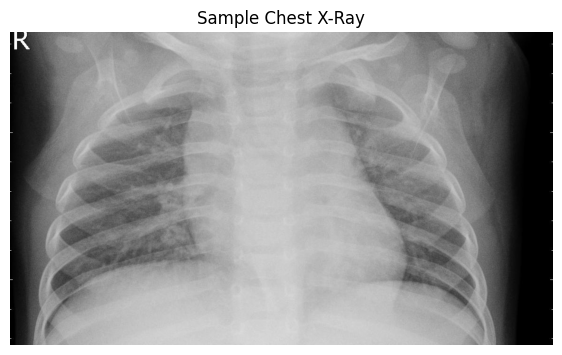

In [28]:
# ============================================================
# DISPLAY SAMPLE X-RAY
# ============================================================

if len(image_files) > 0:

    image_path = image_files[0]

    image = Image.open(image_path)

    print("Image size:", image.size)
    print("Image mode:", image.mode)

    plt.figure(figsize=(7, 7))

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.axis("off")
    plt.title("Sample Chest X-Ray")

    plt.show()

In [29]:
# ============================================================
# IMAGE CLEANING
# ============================================================

def clean_xray(image_path):

    image = Image.open(image_path)

    # Remove image metadata by creating a new image
    image = image.convert("L")

    # Resize
    image = image.resize(
        (224, 224)
    )

    return image


clean_image = clean_xray(
    image_files[0]
)

print("Cleaned image size:", clean_image.size)

Cleaned image size: (224, 224)


In [30]:
# ============================================================
# IMAGE NORMALIZATION
# ============================================================

image_array = np.array(
    clean_image,
    dtype=np.float32
)

print("Pixel range BEFORE normalization:")
print(
    image_array.min(),
    "to",
    image_array.max()
)

# Normalize 0-255 → 0-1
image_normalized = image_array / 255.0

print("\nPixel range AFTER normalization:")
print(
    image_normalized.min(),
    "to",
    image_normalized.max()
)

Pixel range BEFORE normalization:
0.0 to 255.0

Pixel range AFTER normalization:
0.0 to 1.0


In [31]:
# ============================================================
# IMAGE → MODEL READY TENSOR
# ============================================================

image_tensor = np.expand_dims(
    image_normalized,
    axis=-1
)

print("Image tensor shape:")
print(image_tensor.shape)

Image tensor shape:
(224, 224, 1)


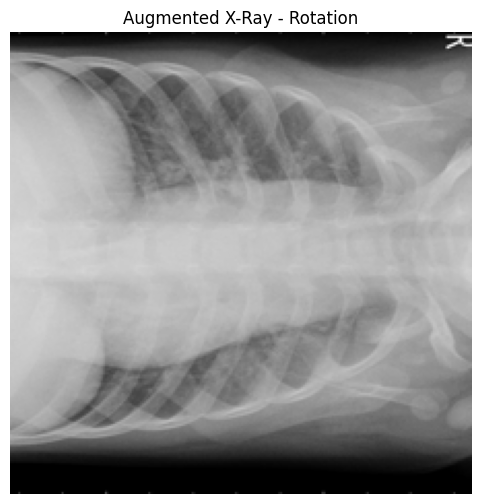

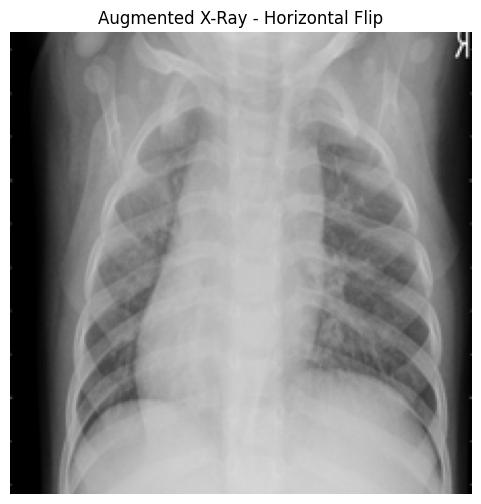

In [32]:
# ============================================================
# IMAGE AUGMENTATION
# ============================================================

image_uint8 = (
    image_normalized * 255
).astype(np.uint8)

# Rotate
rotated_image = cv2.rotate(
    image_uint8,
    cv2.ROTATE_90_CLOCKWISE
)

# Horizontal flip
flipped_image = cv2.flip(
    image_uint8,
    1
)

plt.figure(figsize=(6, 6))

plt.imshow(
    rotated_image,
    cmap="gray"
)

plt.axis("off")
plt.title("Augmented X-Ray - Rotation")

plt.show()

plt.figure(figsize=(6, 6))

plt.imshow(
    flipped_image,
    cmap="gray"
)

plt.axis("off")
plt.title("Augmented X-Ray - Horizontal Flip")

plt.show()

In [33]:
# ============================================================
# CREATE A SMALL IMAGE BATCH
# ============================================================

MAX_IMAGES = min(
    20,
    len(image_files)
)

image_batch = []

image_labels = []

for path in image_files[:MAX_IMAGES]:

    try:

        img = clean_xray(path)

        arr = np.array(
            img,
            dtype=np.float32
        ) / 255.0

        # Add channel dimension
        arr = np.expand_dims(
            arr,
            axis=-1
        )

        image_batch.append(arr)

        if "NORMAL" in path.upper():
            image_labels.append(0)
        else:
            image_labels.append(1)

    except Exception:
        pass


image_batch = np.array(
    image_batch
)

image_labels = np.array(
    image_labels
)

print("Image batch shape:", image_batch.shape)
print("Labels shape:", image_labels.shape)

Image batch shape: (20, 224, 224, 1)
Labels shape: (20,)


Part D

In [34]:
# ============================================================
# PART D: SIGNAL DATA
# MIT-BIH ARRHYTHMIA DATABASE
# ============================================================

record_name = "100"

try:

    record = wfdb.rdrecord(
        record_name,
        pn_dir="mitdb"
    )

    annotation = wfdb.rdann(
        record_name,
        "atr",
        pn_dir="mitdb"
    )

    print("ECG record loaded successfully!")

except Exception as e:

    print("Could not download ECG record automatically.")
    print("Error:", e)

ECG record loaded successfully!


In [35]:
# ============================================================
# ECG DATA INSPECTION
# ============================================================

print("Sampling Frequency:", record.fs, "Hz")

print("Number of Samples:", record.sig_len)

print("Number of Channels:", record.n_sig)

print("Signal Names:", record.sig_name)

print("Number of Annotations:", len(annotation.sample))

Sampling Frequency: 360 Hz
Number of Samples: 650000
Number of Channels: 2
Signal Names: ['MLII', 'V5']
Number of Annotations: 2274


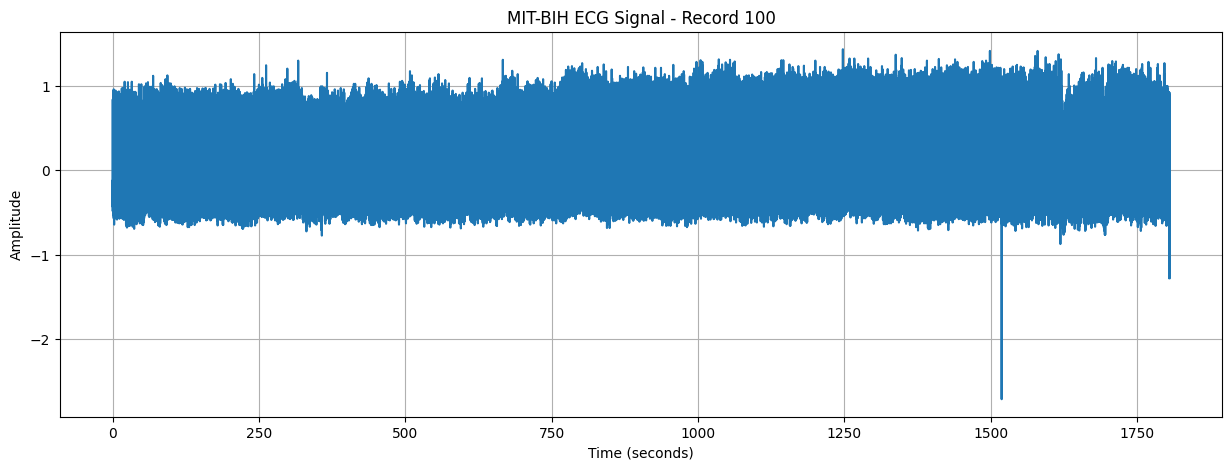

In [36]:
# ============================================================
# ECG VISUALIZATION
# ============================================================

plt.figure(figsize=(15, 5))

time = np.arange(
    record.sig_len
) / record.fs

plt.plot(
    time,
    record.p_signal[:, 0]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("MIT-BIH ECG Signal - Record 100")

plt.grid()

plt.show()

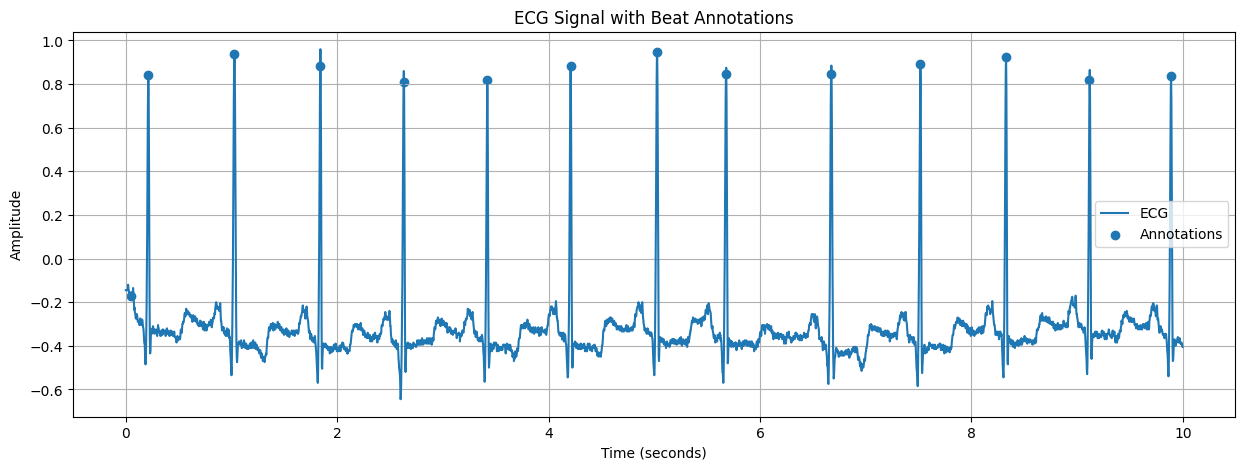

In [37]:
# ============================================================
# ECG WITH ANNOTATIONS
# ============================================================

samples = annotation.sample

# Show first 10 seconds
max_samples = int(
    10 * record.fs
)

signal = record.p_signal[:max_samples, 0]

time = np.arange(
    len(signal)
) / record.fs

annotation_samples = samples[
    samples < max_samples
]

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    signal,
    label="ECG"
)

plt.scatter(
    annotation_samples / record.fs,
    signal[annotation_samples],
    marker="o",
    label="Annotations"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.title(
    "ECG Signal with Beat Annotations"
)

plt.legend()
plt.grid()

plt.show()

In [38]:
# ============================================================
# ECG NOISE REMOVAL
# BAND-PASS FILTER
# ============================================================

def bandpass_filter(
    signal,
    lowcut,
    highcut,
    fs,
    order=4
):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(
        order,
        [low, high],
        btype="band"
    )

    filtered = filtfilt(
        b,
        a,
        signal
    )

    return filtered


ecg_signal = record.p_signal[:, 0]

filtered_ecg = bandpass_filter(
    ecg_signal,
    lowcut=0.5,
    highcut=40,
    fs=record.fs
)

print("ECG noise removal completed.")

ECG noise removal completed.


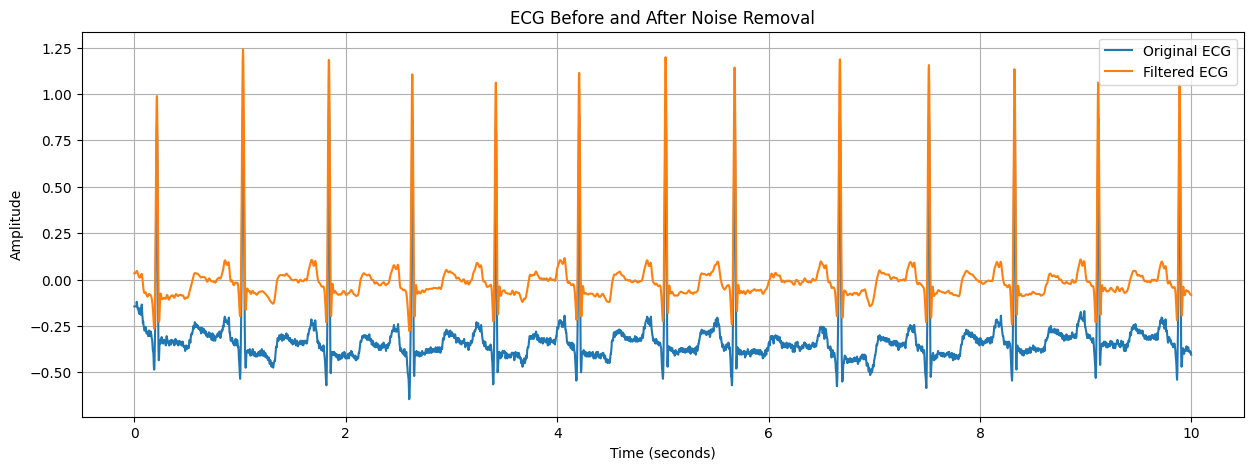

In [39]:
# ============================================================
# ORIGINAL VS FILTERED ECG
# ============================================================

seconds_to_plot = 10

N = int(
    seconds_to_plot * record.fs
)

time = np.arange(N) / record.fs

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    ecg_signal[:N],
    label="Original ECG"
)

plt.plot(
    time,
    filtered_ecg[:N],
    label="Filtered ECG"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.title(
    "ECG Before and After Noise Removal"
)

plt.legend()
plt.grid()

plt.show()

In [40]:
# ============================================================
# ECG SIGNAL WINDOWING
# ============================================================

window_seconds = 5

window_size = int(
    window_seconds * record.fs
)

num_windows = (
    len(filtered_ecg) // window_size
)

signal_windows = []

for i in range(num_windows):

    start = i * window_size
    end = start + window_size

    window = filtered_ecg[
        start:end
    ]

    if len(window) == window_size:
        signal_windows.append(window)


signal_windows = np.array(
    signal_windows
)

print("Number of signal windows:", len(signal_windows))

print("Signal window shape:",
      signal_windows.shape)

Number of signal windows: 361
Signal window shape: (361, 1800)


In [41]:
# ============================================================
# NORMALIZE ECG WINDOWS
# ============================================================

signal_scaler = MinMaxScaler()

normalized_windows = []

for window in signal_windows:

    normalized = signal_scaler.fit_transform(
        window.reshape(-1, 1)
    ).flatten()

    normalized_windows.append(
        normalized
    )

normalized_windows = np.array(
    normalized_windows
)

print(
    "Normalized signal windows:",
    normalized_windows.shape
)

Normalized signal windows: (361, 1800)


In [42]:
# ============================================================
# ECG FEATURE EXTRACTION
# ============================================================

def extract_signal_features(window):

    features = {
        "mean": np.mean(window),
        "std": np.std(window),
        "min": np.min(window),
        "max": np.max(window),
        "range": np.ptp(window),
        "energy": np.mean(window ** 2)
    }

    return features


signal_features = pd.DataFrame(
    [
        extract_signal_features(window)
        for window in normalized_windows
    ]
)

display(signal_features.head())

,mean,std,min,max,range,energy
0,0.181300,0.105042,0.0,1.0,1.0,0.043903
1,0.170318,0.118475,0.0,1.0,1.0,0.043044
2,0.179219,0.110854,0.0,1.0,1.0,0.044408
3,0.162137,0.111987,0.0,1.0,1.0,0.038829
4,0.165819,0.107767,0.0,1.0,1.0,0.039110


In [43]:
# ============================================================
# SIGNAL FEATURE SUMMARY
# ============================================================

display(
    signal_features.describe()
)

,mean,std,min,max,range,energy
count,361.000000,361.000000,361.0,3.610000e+02,3.610000e+02,361.000000
mean,0.166319,0.111583,0.0,1.000000e+00,1.000000e+00,0.041044
std,0.030071,0.005402,0.0,7.166459e-17,7.166459e-17,0.020925
min,0.127054,0.084201,0.0,1.000000e+00,1.000000e+00,0.026822
25%,0.154453,0.108505,0.0,1.000000e+00,1.000000e+00,0.036289
50%,0.162391,0.111269,0.0,1.000000e+00,1.000000e+00,0.038979
75%,0.174504,0.114690,0.0,1.000000e+00,1.000000e+00,0.042801
max,0.643571,0.126920,0.0,1.000000e+00,1.000000e+00,0.421273


In [44]:
# ============================================================
# MULTIMODAL PROCESSING SUMMARY
# ============================================================

print("=" * 70)
print("           LAB ASSIGNMENT - 3 COMPLETED")
print("=" * 70)

print("\nA. TABULAR DATA")
print("   Dataset: Pima Indians Diabetes Dataset")
print("   ✓ Data acquisition")
print("   ✓ Dataset inspection")
print("   ✓ Healthcare-specific missing value detection")
print("   ✓ Missing value imputation")
print("   ✓ EDA")
print("   ✓ Hypothesis testing")
print("   ✓ Chi-square test")
print("   ✓ ANOVA")
print("   ✓ Feature engineering")
print("   ✓ Feature selection")
print("   ✓ PCA feature extraction")

print("\nB. TEXTUAL DATA")
print("   Dataset: MTSamples Medical Transcriptions")
print("   ✓ Text acquisition")
print("   ✓ PHI de-identification")
print("   ✓ Text cleaning")
print("   ✓ Tokenization")
print("   ✓ Stopword removal")
print("   ✓ Keyword extraction")
print("   ✓ TF-IDF representation")

print("\nC. IMAGE DATA")
print("   Dataset: Chest X-Ray Pneumonia")
print("   ✓ Image acquisition")
print("   ✓ Image inspection")
print("   ✓ Metadata-safe image conversion")
print("   ✓ Resizing")
print("   ✓ Normalization")
print("   ✓ Tensor creation")
print("   ✓ Image augmentation")

print("\nD. SIGNAL DATA")
print("   Dataset: MIT-BIH Arrhythmia Database")
print("   ✓ ECG acquisition")
print("   ✓ Signal inspection")
print("   ✓ ECG visualization")
print("   ✓ Annotation visualization")
print("   ✓ Noise removal")
print("   ✓ Signal windowing")
print("   ✓ Normalization")
print("   ✓ Feature extraction")

print("\n" + "=" * 70)
print("        MULTIMODAL HEALTHCARE DATA PIPELINE DONE")
print("=" * 70)

           LAB ASSIGNMENT - 3 COMPLETED

A. TABULAR DATA
   Dataset: Pima Indians Diabetes Dataset
   ✓ Data acquisition
   ✓ Dataset inspection
   ✓ Healthcare-specific missing value detection
   ✓ Missing value imputation
   ✓ EDA
   ✓ Hypothesis testing
   ✓ Chi-square test
   ✓ ANOVA
   ✓ Feature engineering
   ✓ Feature selection
   ✓ PCA feature extraction

B. TEXTUAL DATA
   Dataset: MTSamples Medical Transcriptions
   ✓ Text acquisition
   ✓ PHI de-identification
   ✓ Text cleaning
   ✓ Tokenization
   ✓ Stopword removal
   ✓ Keyword extraction
   ✓ TF-IDF representation

C. IMAGE DATA
   Dataset: Chest X-Ray Pneumonia
   ✓ Image acquisition
   ✓ Image inspection
   ✓ Metadata-safe image conversion
   ✓ Resizing
   ✓ Normalization
   ✓ Tensor creation
   ✓ Image augmentation

D. SIGNAL DATA
   Dataset: MIT-BIH Arrhythmia Database
   ✓ ECG acquisition
   ✓ Signal inspection
   ✓ ECG visualization
   ✓ Annotation visualization
   ✓ Noise removal
   ✓ Signal windowing
   ✓ Normali